In [1]:
from qiskit import __version__
print(__version__)

2.1.1


In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, state_fidelity, Pauli, DensityMatrix
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit import transpile 
import numpy as np
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError, pauli_error 
from qiskit.circuit.library import HGate, UnitaryGate, IGate
import matplotlib.pyplot as plt
from matplotlib.ticker import NullFormatter

In [3]:
# Create custom gates
H_matrix = HGate().to_matrix()
h_tagged = UnitaryGate(H_matrix, label='s_hadamard')

ID_matrix = IGate().to_matrix()
encoding_err = UnitaryGate(ID_matrix, label='encoding_err')

idle_matrix = IGate().to_matrix()
idle = UnitaryGate(idle_matrix, label='idle')

In [9]:
ideal = Statevector([0.94502682+4.48585114e-15j, 0.        +0.00000000e+00j,
             0.        +0.00000000e+00j, 0.        +0.00000000e+00j,
             0.32699283+1.72372984e-15j, 0.        +0.00000000e+00j,
             0.        +0.00000000e+00j, 0.        +0.00000000e+00j],
            dims=(2, 2, 2))

In [5]:
theta = np.arctan(np.sqrt((np.sqrt(5) - 1) / 2))
amp_0 = np.cos(theta/2)
amp_1 = np.sin(theta/2)

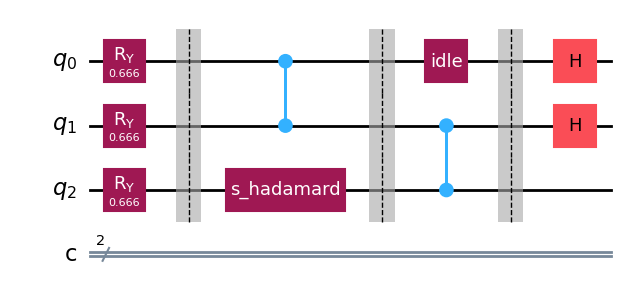

In [7]:
circuit = QuantumCircuit(3, 2)

# State prep
for i in range(3):
    circuit.ry(theta, i)
circuit.barrier()

circuit.cz(0,1)
circuit.append(h_tagged, [2])
circuit.barrier()
    
circuit.append(idle, [0])
circuit.cz(1,2)
circuit.barrier()

circuit.h(0)
circuit.h(1)

display(circuit.draw(output='mpl'))

In [10]:
one_qubit_noise = []
for i in range(1, 7):
    one_qubit_noise.append(np.round((0.00002*i), 5)) # Quantinuum 1Q Gate 
    
meas_noise = []
for i in range(1, 7):
    meas_noise.append(np.round((0.0015*i), 4)) # Quantinuum SPAM 
    
two_qubit_noise = []
for i in range(1, 7):
    two_qubit_noise.append(np.round((0.0016*i), 4)) # Quantinuum 2Q Gate

In [11]:
fidelity_results = {}
sample_err_rate = []

for i in range(len(one_qubit_noise)):
    # New noise model for each depolarizing probability
    noise_model = NoiseModel()

    # Apply depolarizing error with probability p
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_noise[i], 1), ['ry'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_noise[i], 1), ['s_hadamard'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_noise[i], 1), ['idle'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(two_qubit_noise[i], 2), ['cz']) 

    # Keep readout error constant
    readout_err = ReadoutError([[1-meas_noise[i], meas_noise[i]],  # P(measured 0 | actual 0), P(1 | 0)
                            [meas_noise[i], 1-meas_noise[i]]]) # P(0 | 1), P(1 | 1)
    noise_model.add_readout_error(readout_err, [0])
    noise_model.add_readout_error(readout_err, [1])
    
    # A copy of the circuit
    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([0, 1], [0, 1]) 
    meas_circuit_noise.save_statevector(label='state_post', pershot=True, conditional=True)

    # Run simulation
    backend = AerSimulator(noise_model=noise_model)
    transpiled = transpile(meas_circuit_noise, backend, optimization_level=0)
    job = backend.run(transpiled, shots=1_000_000)
    result = job.result()
    
    # Extract final state and compute fidelity 
    res_statevectors = result.data()['state_post']
    num_meas = len(res_statevectors['0x0'])
    sumfid = 0
    for shot in res_statevectors['0x0']:
        sumfid += state_fidelity(shot, ideal)
    sumfid /= num_meas
    
    fidelity_results[i] = sumfid
    
    # Calculating error rate for uncertainty calculations
    sample_err_rate.append(1.96 * np.sqrt( (sumfid)*(1 - sumfid) / num_meas) )

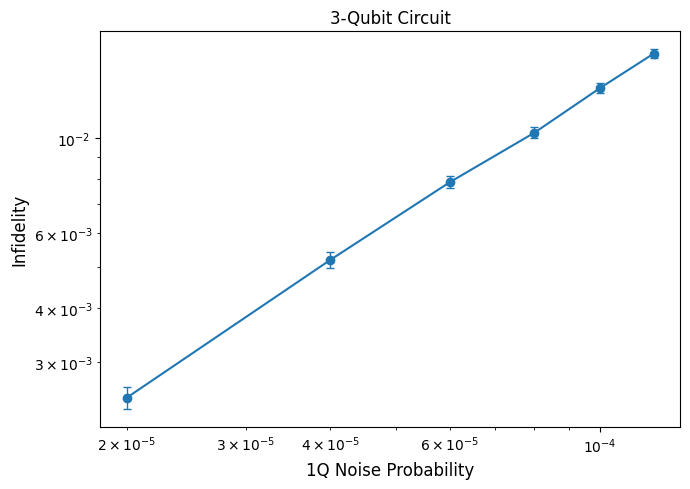

In [12]:
infidelities = [1 - fidelity_results[p] for p in range(len(one_qubit_noise))]

fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(
    one_qubit_noise,
    infidelities,
    yerr=sample_err_rate,
    fmt='o-',
    capsize=3,
    elinewidth=1,
    markeredgewidth=1
)

ax.set_xlabel("1Q Noise Probability", fontsize=12)
ax.set_ylabel("Infidelity", fontsize=12)
ax.set_xscale('log')
ax.set_yscale('log')
#ax.grid(True)
"""
# Turn off both major and minor tick formatters (default log labels)
ax.xaxis.set_major_formatter(NullFormatter())
ax.xaxis.set_minor_formatter(NullFormatter())

# Set desired ticks and labels
ax.set_xticks(depol_probs_encoding)
ax.set_xticklabels([f"{x:.2e}" for x in depol_probs_encoding], fontsize=8, rotation=30)
"""
plt.title("3-Qubit Circuit")
plt.tight_layout()
plt.show()

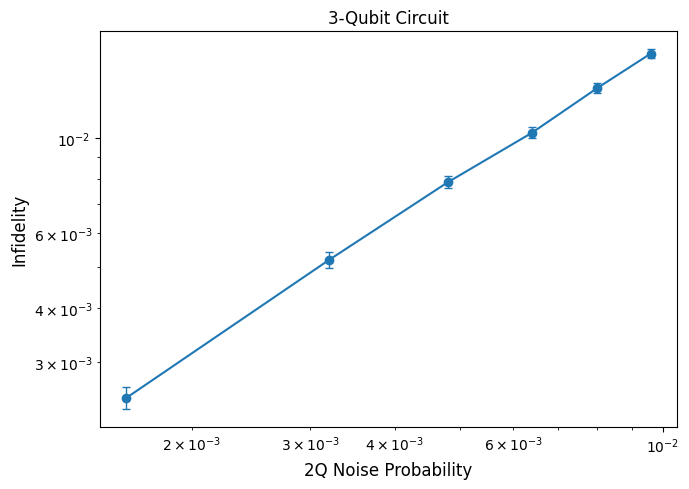

In [13]:
infidelities = [1 - fidelity_results[p] for p in range(len(one_qubit_noise))]

fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(
    two_qubit_noise,
    infidelities,
    yerr=sample_err_rate,
    fmt='o-',
    capsize=3,
    elinewidth=1,
    markeredgewidth=1
)

ax.set_xlabel("2Q Noise Probability", fontsize=12)
ax.set_ylabel("Infidelity", fontsize=12)
ax.set_xscale('log')
ax.set_yscale('log')
#ax.grid(True)
"""
# Turn off both major and minor tick formatters (default log labels)
ax.xaxis.set_major_formatter(NullFormatter())
ax.xaxis.set_minor_formatter(NullFormatter())

# Set desired ticks and labels
ax.set_xticks(depol_probs_encoding)
ax.set_xticklabels([f"{x:.2e}" for x in depol_probs_encoding], fontsize=8, rotation=30)
"""
plt.title("3-Qubit Circuit")
plt.tight_layout()
plt.show()

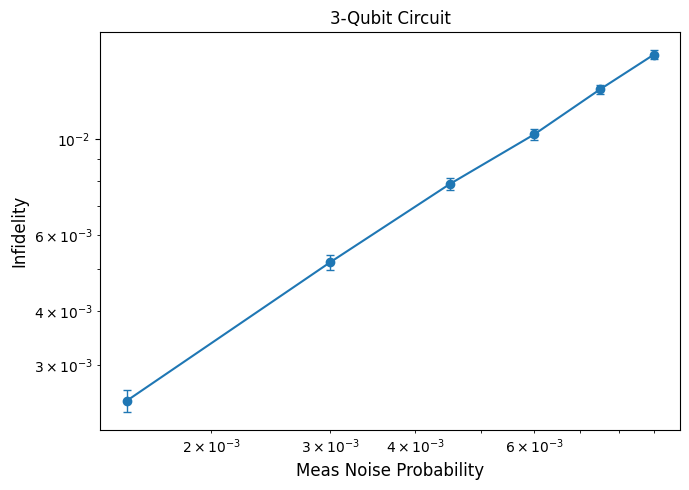

In [14]:
infidelities = [1 - fidelity_results[p] for p in range(len(one_qubit_noise))]

fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(
    meas_noise,
    infidelities,
    yerr=sample_err_rate,
    fmt='o-',
    capsize=3,
    elinewidth=1,
    markeredgewidth=1
)

ax.set_xlabel("Meas Noise Probability", fontsize=12)
ax.set_ylabel("Infidelity", fontsize=12)
ax.set_xscale('log')
ax.set_yscale('log')
#ax.grid(True)
"""
# Turn off both major and minor tick formatters (default log labels)
ax.xaxis.set_major_formatter(NullFormatter())
ax.xaxis.set_minor_formatter(NullFormatter())

# Set desired ticks and labels
ax.set_xticks(depol_probs_encoding)
ax.set_xticklabels([f"{x:.2e}" for x in depol_probs_encoding], fontsize=8, rotation=30)
"""
plt.title("3-Qubit Circuit")
plt.tight_layout()
plt.show()